In [1]:
%load_ext autoreload
%autoreload 2
import os, sys

import PATH
import scanpy as sc

import numpy as np
from src import _sampler
from src import _reader

import torch
from torch import nn
from matplotlib import pyplot as plt

## Visualize norman data

In [2]:
# load the AnnData
data_dir = "/data/users/wergillius/CPA+GEARS/cpa_datasets"
data_path = 'Norman2019_prep_new.h5ad'
norman_cdata = sc.read(os.path.join(data_dir, data_path))

In [32]:
sc.tl.pca(norman_cdata)
sc.pp.neighbors(norman_cdata)
sc.tl.umap(norman_cdata)
sc.tl.leiden(norman_cdata)

In [37]:
norman_cdata.obs['pert1'] = norman_cdata.obs['condition'].apply(lambda x: x.split("+")[0])
norman_cdata.obs['pert2'] = norman_cdata.obs['condition'].apply(lambda x: x.split("+")[-1])
# unique tokens
unique_token = list(set(norman_cdata.obs['pert1'].tolist() + norman_cdata.obs['pert2'].tolist()))
unique_token.remove('ctrl')
unique_token = ['ctrl'] + unique_token
unique_token_dict = {token:i for i, token in enumerate(unique_token)}
reverse_token_dict = {i:token for token, i in unique_token_dict.items()}
norman_cdata.uns['condition_token'] = unique_token_dict

In [ ]:
# recolor
big_color_list = sc.pl.palettes.zeileis_28 +sc.pl.palettes.godsnot_102
norman_cdata.uns['pert1_colors'] = big_color_list[:105]
norman_cdata.uns['pert1_colors'][-1] = "#FFFFFF"

In [362]:
norman_cdaata.write_h5ad(os.path.join(data_dir, data_path))

In [365]:
sc.tl.diffmap(norman_cdata)

In [363]:
norman_cdata

AnnData object with n_obs × n_vars = 108497 × 5000
    obs: 'cov_drug_dose_name', 'dose_val', 'control', 'condition', 'guide_identity', 'drug_dose_name', 'cell_type', 'split', 'split1', 'split2', 'split3', 'split4', 'split5', 'split6', 'split7', 'split8', 'split9', 'split10', 'split11', 'split12', 'split13', 'split14', 'split15', 'split16', 'split17', 'split18', 'split19', 'split20', 'split21', 'split22', 'split23', 'split24', 'split25', 'leiden', 'pert1', 'pert2'
    var: 'gene_symbols', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'rank_genes_groups_cov', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'pert1_colors', 'condition_token', 'pert2_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [78]:
cond1 = np.random.choice(unique_token)

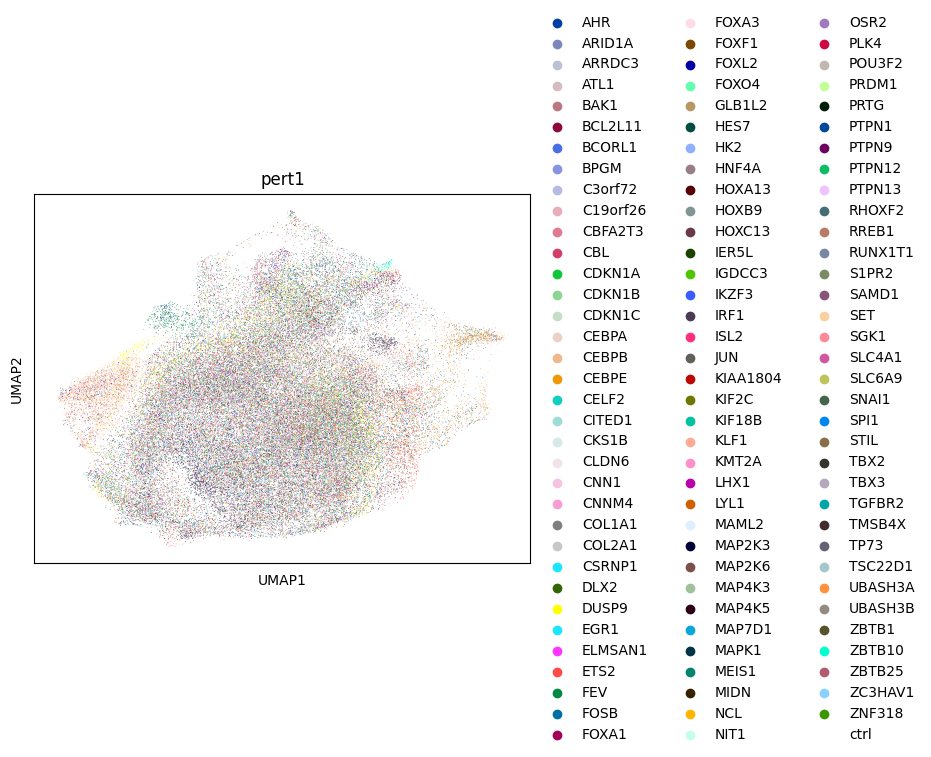

In [171]:
sc.pl.umap(norman_cdata, color='pert1')

SNAI1


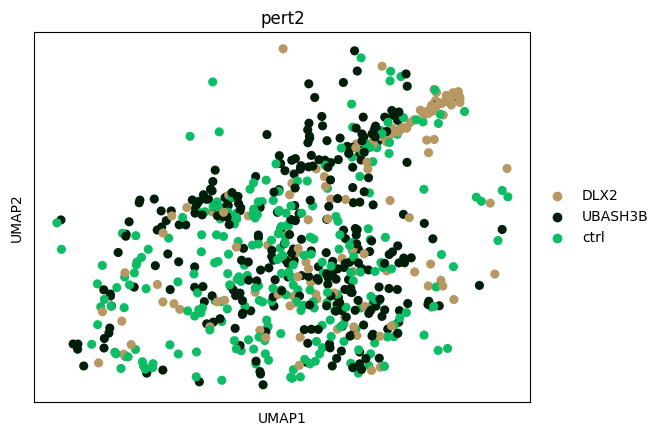

In [542]:
cond1 = np.random.choice(unique_token)
print(cond1)
sc.pl.umap(norman_cdata[norman_cdata.obs['pert1'] == cond1].copy(), 
           color='pert2', color_map="magma")

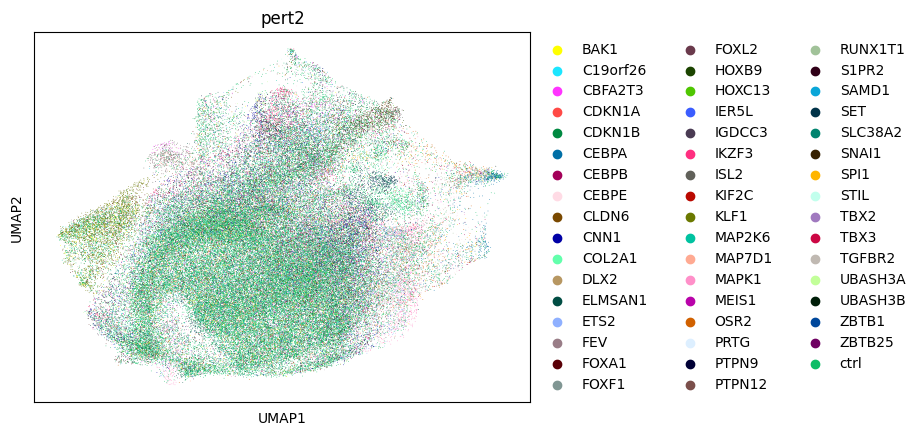

In [130]:
sc.pl.umap(norman_cdata, color='pert2', color_map="magma")

In [176]:
first50cond1 = unique_token[1:50]

In [177]:
subset_adata=norman_cdata[norman_cdata.obs.query("`pert1` in @first50cond1").index].copy()

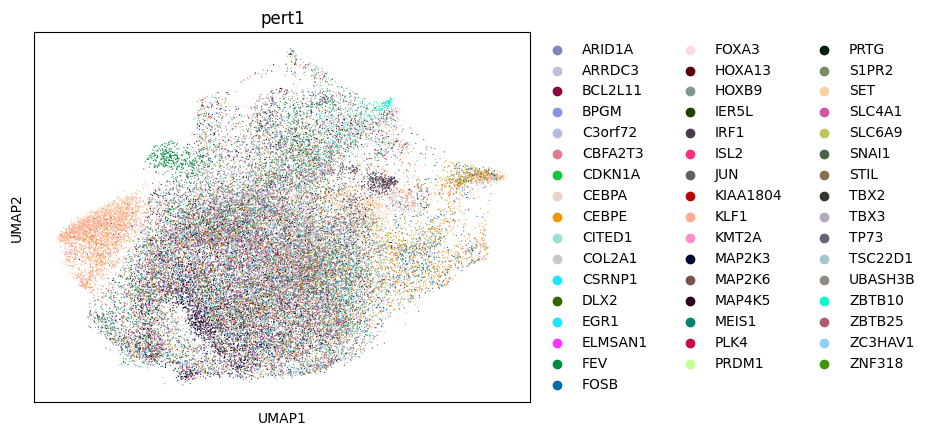

In [178]:
sc.pl.umap(subset_adata,
           color='pert1')

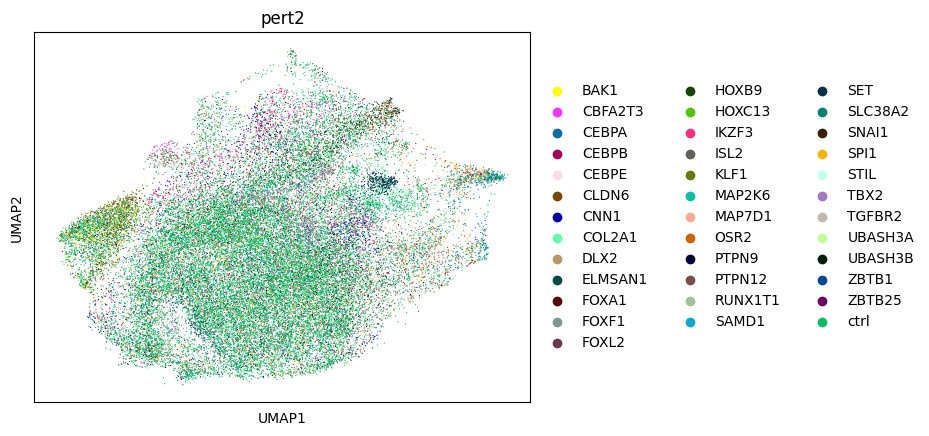

In [150]:
sc.pl.umap(subset_adata,
           color='pert2', color_map="magma")

In [273]:
colormapper=dict(zip(cond1_data.obs['pert2'].unique(), sc.pl.palettes.zeileis_28[:5]))

In [274]:
colormapper

{'ctrl': '#023fa5',
 'CEBPE': '#7d87b9',
 'CEBPB': '#bec1d4',
 'OSR2': '#d6bcc0',
 'UBASH3B': '#bb7784'}

In [226]:
cond1_data.obs['pert2'].unique()

['ctrl']
Categories (1, object): ['ctrl']

In [322]:
from src import _configure
from src import evalutation_utils as eu

MAP2K6


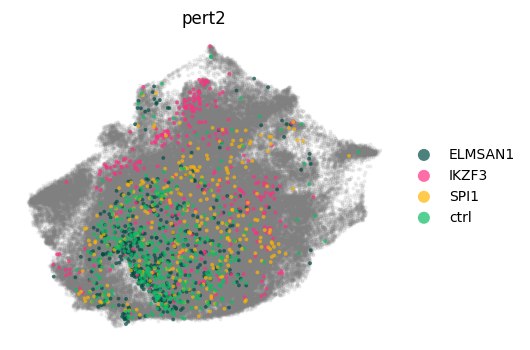

In [565]:
cond1 = np.random.choice(unique_token[1:50])
print(cond1)

fig, ax = eu.condition_on_umap(norman_cdata, cond1)

## Load models

In [188]:
from src import _configure
from src import _sampler

In [179]:
# load the recon model
save_path = "/data/users/wergillius/diffuse_differentiate/Epsilon_Linear/beta_lineaer_3hidden.pth"
eps_net = torch.load(save_path, map_location='cpu')

In [184]:
config_path = "configs/Norman_DDPM_recon/beta_lineaer_5hidden.yaml"

In [185]:
configs = _configure.Yaml_configurer(os.path.join(PATH.main_dir,config_path))

In [189]:
Samper_Class = eval("_sampler.%s" %configs.sampler_class)
sampler_kwargs = configs.sampler_kwargs
sampler_kwargs['model'] = eps_net

Sampler = Samper_Class(**sampler_kwargs)

In [387]:
Sampler.total_timestep

200

## sample some data from annData

In [333]:
# from test set
train_anndata = norman_cdata[norman_cdata.obs['split'] == 'train'].copy()
test_anndata = norman_cdata[norman_cdata.obs['split'] == 'test'].copy()

In [334]:
train_anndata.obs['pert1'].unique()

['ctrl', 'TSC22D1', 'KLF1', 'CEBPE', 'MAML2', ..., 'PRDM1', 'HK2', 'EGR1', 'IER5L', 'STIL']
Length: 105
Categories (105, object): ['ctrl', 'TSC22D1', 'KLF1', 'CEBPE', ..., 'HK2', 'EGR1', 'IER5L', 'STIL']

In [336]:
test_anndata.obs['pert1'].unique()

['ctrl', 'DUSP9', 'IGDCC3', 'CELF2', 'CEBPE', ..., 'PRTG', 'HOXA13', 'HNF4A', 'CITED1', 'HES7']
Length: 105
Categories (105, object): ['ctrl', 'DUSP9', 'IGDCC3', 'CELF2', ..., 'HOXA13', 'HNF4A', 'CITED1', 'HES7']

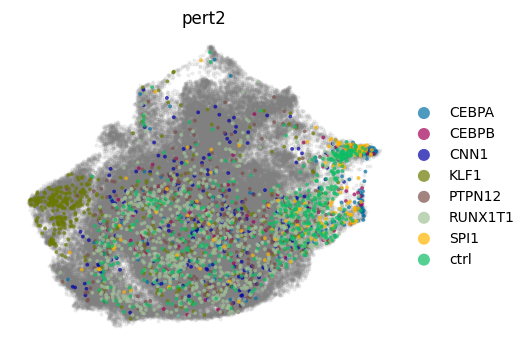

In [685]:
eu.condition_on_umap(train_anndata, 'CEBPE');

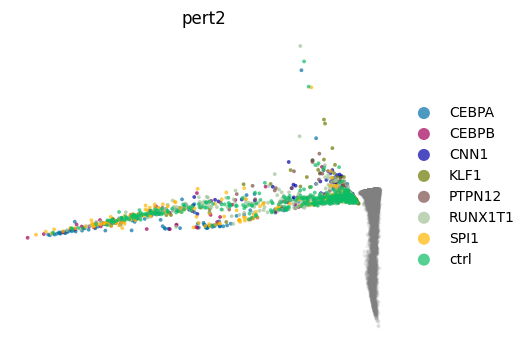

(<Figure size 500x400 with 1 Axes>, <AxesSubplot:title={'center':'pert2'}>)

In [687]:
eu.condition_on_umap(norman_cdata, basis='diffmap', c1='CEBPE')

## pick `KLF1` and `COL2A1` as test conditions

In [617]:
# condition
c1 = 'KLF1'
c2 = 'COL2A1'
c_ay = np.array([norman_cdata.uns['condition_token'][c] for c in [c1,c2]])

In [689]:
# condition
c1 = 'CEBPE'
c2 = 'CNN1'
c_ay = np.array([norman_cdata.uns['condition_token'][c] for c in [c1,c2]])

In [715]:
# condition
c1 = "AHR"
c2 = "KLF1"
c_ay = np.array([norman_cdata.uns['condition_token'][c] for c in [c1,c2]])

In [716]:
# select cells having these 2 conditions at the same time
cellbarcodes = norman_cdata.obs.query("`pert1`==@c1 & `pert2` == @c2").index
sampled_data = norman_cdata[cellbarcodes].copy()

In [717]:
sampled_data

AnnData object with n_obs × n_vars = 481 × 5000
    obs: 'cov_drug_dose_name', 'dose_val', 'control', 'condition', 'guide_identity', 'drug_dose_name', 'cell_type', 'split', 'split1', 'split2', 'split3', 'split4', 'split5', 'split6', 'split7', 'split8', 'split9', 'split10', 'split11', 'split12', 'split13', 'split14', 'split15', 'split16', 'split17', 'split18', 'split19', 'split20', 'split21', 'split22', 'split23', 'split24', 'split25', 'leiden', 'pert1', 'pert2'
    var: 'gene_symbols', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'rank_genes_groups_cov', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'pert1_colors', 'condition_token', 'pert2_colors', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [718]:
from torch.utils.data import DataLoader

In [719]:
b=32
train_set = _reader.Condition_AnnDataSet(sampled_data, unique_token_dict)
train_dl = iter(DataLoader(train_set, batch_size=b, shuffle=True))

def return_next_batch(t=None):
    X, c = next(train_dl)
    #if specify a timestep t
    if t:
        T_b = torch.full((32,), t).long()
    else:
        T_b = torch.from_numpy(np.random.randint(0, 400, (32,)))
    Exp_batch = None
    return X, T_b, Exp_batch, c

<font color='#618CAC'>**start with q-sample**  
    
This fucntion will gradually add noise to the expression matrix

In [720]:
X_0, T_b, Exp_batch, c = return_next_batch()

In [721]:
X_0.max()

tensor(766.)

In [722]:
reorder = np.argsort(c[:,1].numpy())
c = c[reorder]
X_0 = X_0[reorder]

all_c = np.unique(c.numpy(), axis=0)

In [723]:
condition_list=list(norman_cdata.uns['condition_token'].keys())
marker_var_indexes=[]
for c1i, c2i in all_c:
    c1 = condition_list[c1i]
    c2 = condition_list[c2i]
    marker_genes=norman_cdata.uns['rank_genes_groups_cov'][f"A549_{c1}+{c2}_1+1"]
    var_indexs=[i for i,engid in enumerate(sampled_data.var.index) if engid in marker_genes]
    marker_var_indexes +=var_indexs

In [732]:
X_corrupted = [X_0] + Sampler.q_sample_loop(X_0)

Adding noise :: 100%|██████████| 200/200 [00:00<00:00, 450.18it/s]


In [733]:
from src import evalutation_utils as eu

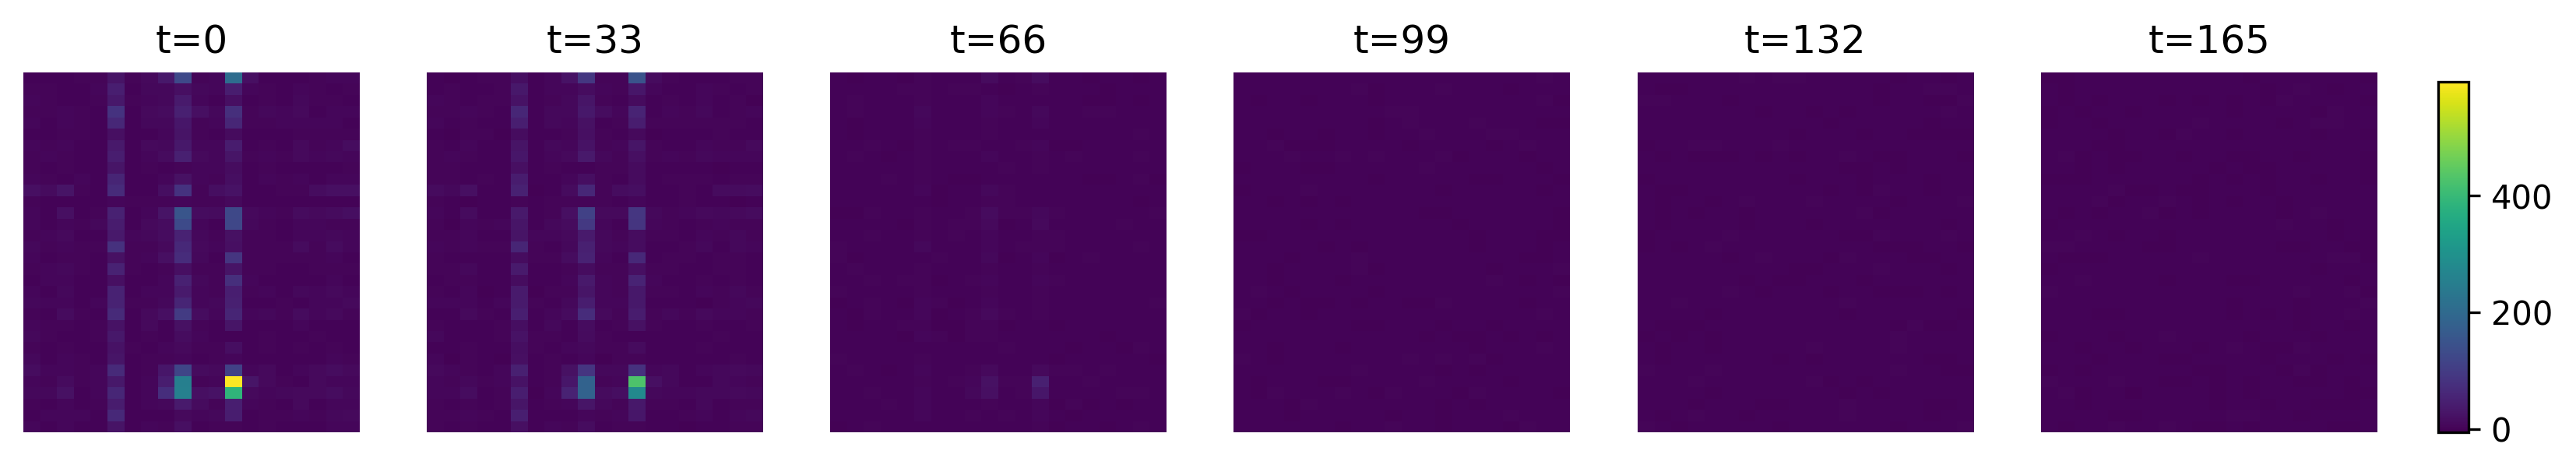

In [734]:
fig, axs, color_norm = eu.Xmat_by_time(X_corrupted, var_indexs=marker_var_indexes, log_transform=False)

In [735]:
T = torch.full((64,), 2).long()

In [736]:
b=32

In [737]:
reconstructed = []
started_from = 99


X_t = X_corrupted[started_from]
c_ts = torch.from_numpy(np.stack([c_ay]*b))

for t in range(started_from,0,-1):
    T = torch.full((b,), t).long()
    
    X_t = Sampler.p_sample(X_t, T, c=c_ts)
    reconstructed.append(X_t)
reconstructed = reconstructed[::-1]

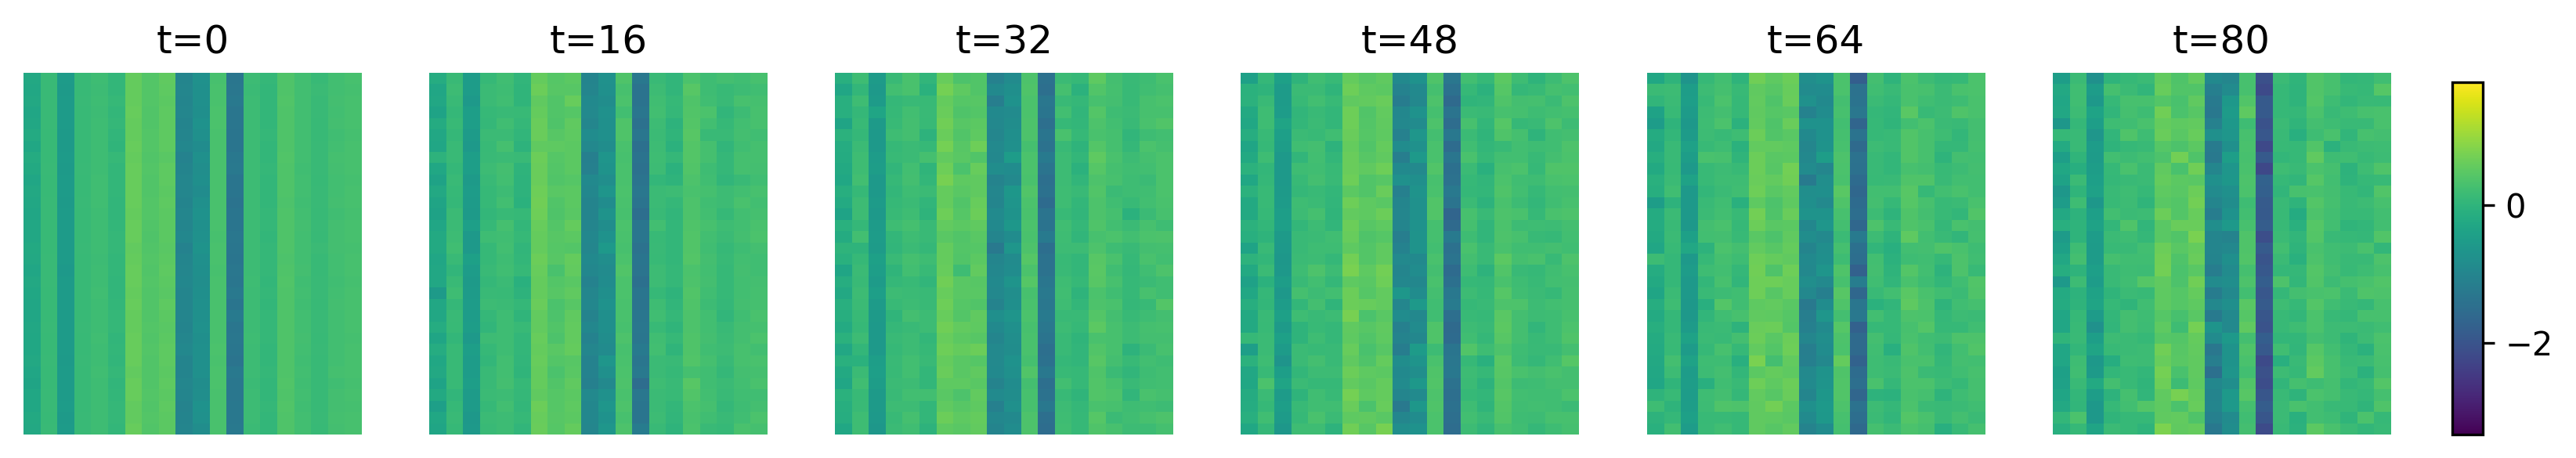

In [738]:
eu.Xmat_by_time(reconstructed, var_indexs=var_indexs,log_transform=False);

In [739]:
denovo_sampling = Sampler.p_sample_loop(shape=X_t.shape, c=c_ts)

Z~N(0,I) → X_0 :: 100%|██████████| 200/200 [00:01<00:00, 138.46it/s]


In [740]:
denovo_sampling = denovo_sampling[::-1]

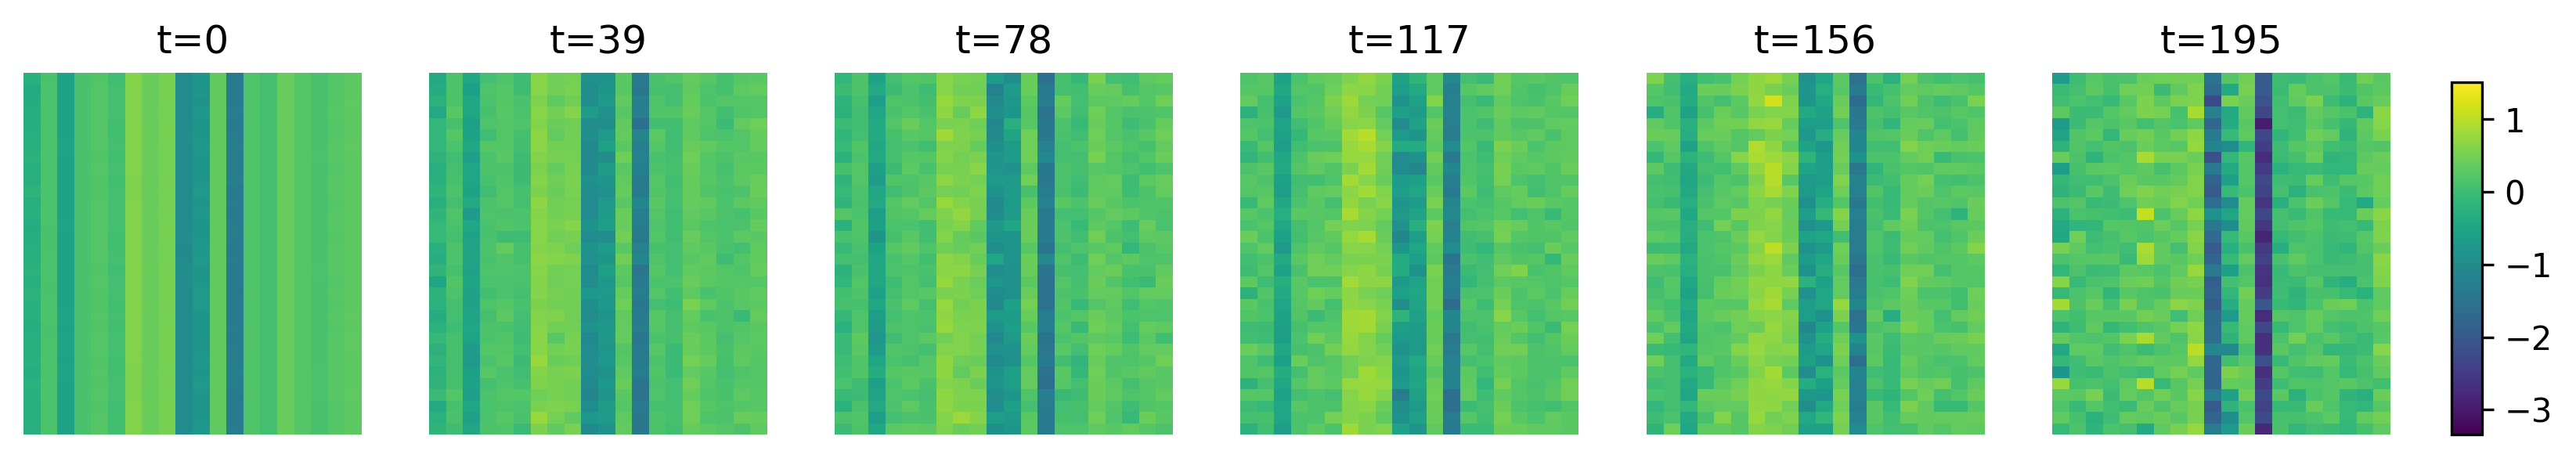

In [741]:
eu.Xmat_by_time(denovo_sampling, time_interval=39 ,var_indexs=var_indexs,log_transform=False);

In [742]:
denovo_sampling = Sampler.p_sample_loop(shape=X_t.shape)

Z~N(0,I) → X_0 :: 100%|██████████| 200/200 [00:01<00:00, 140.85it/s]


In [743]:
denovo_sampling = denovo_sampling[::-1]

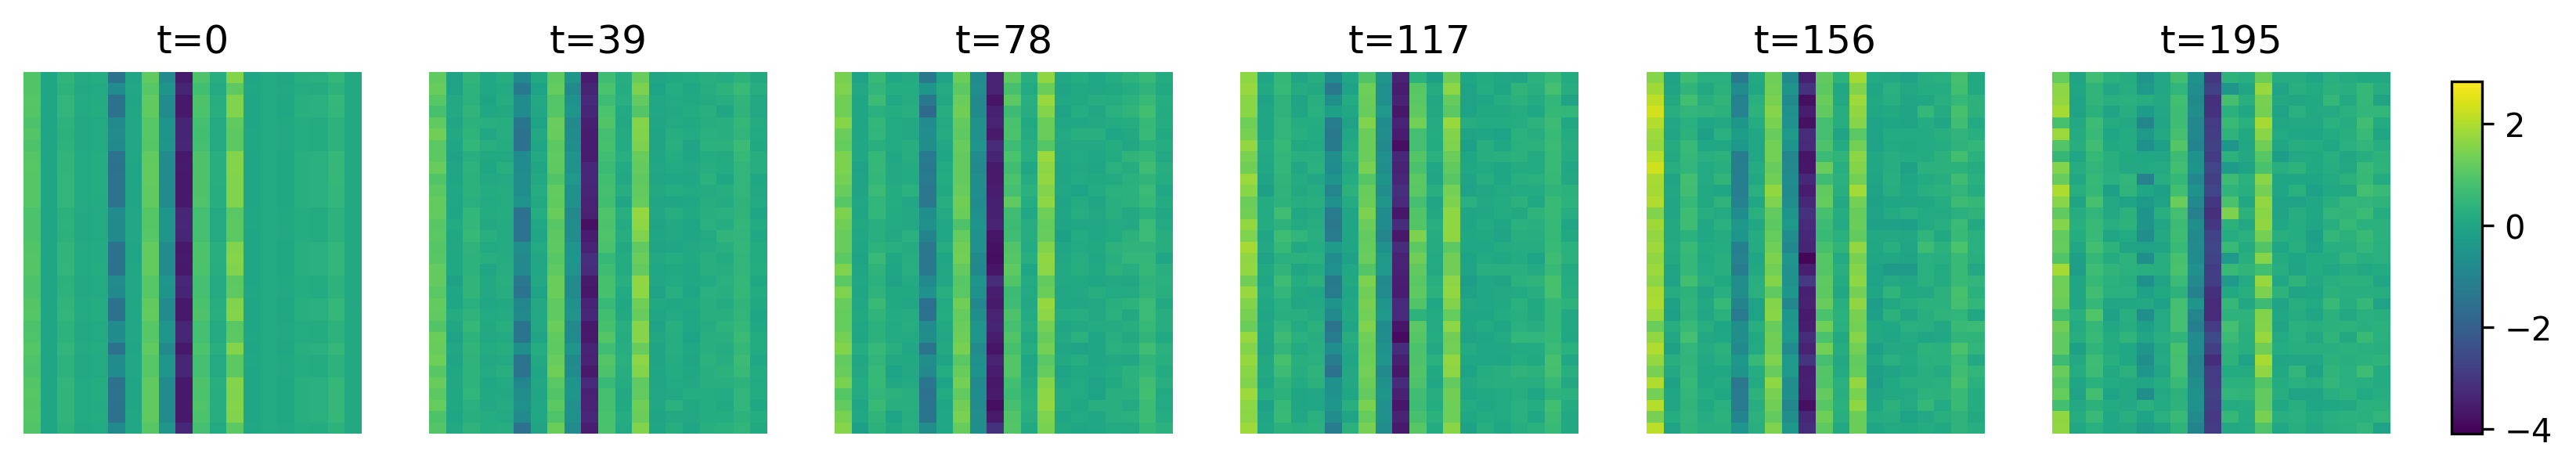

In [744]:
eu.Xmat_by_time(denovo_sampling, time_interval=39 ,var_indexs=var_indexs,log_transform=False);

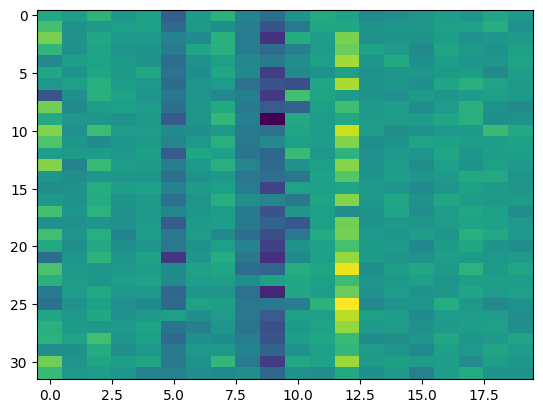

In [745]:
plt.imshow(denovo_sampling[-1][:,var_indexs], aspect='auto')

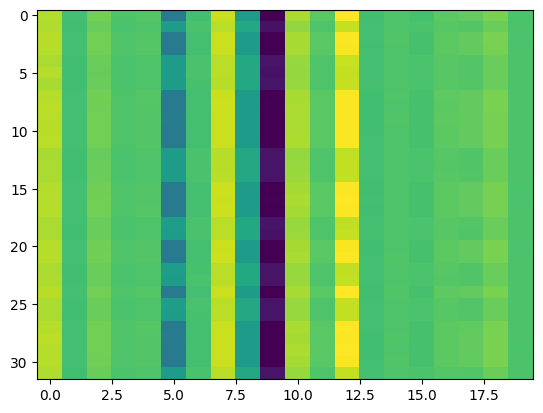

In [746]:
plt.imshow(denovo_sampling[0][:,var_indexs], aspect='auto')